In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import Normalize 

In [3]:
edge_path = Path("mammalia-voles-bhp-trapping/mammalia-voles-bhp-trapping.edges")

# rows have four fields, the 2 nodes (vole 1 and vole 2), the weight 
# (number of co-occurrences), and the session number.
df = pd.read_csv(
    edge_path,
    sep=r"\s+",
    names=["v1", "v2", "w", "s"]
)



Examine the data shape and structure.

In [4]:

print(df.shape)
print(df.head())
print(df.dtypes)

(5324, 4)
   v1  v2  w    s
0   1   2  3  2.0
1   3   4  1  2.0
2   3   5  2  2.0
3   3   6  2  2.0
4   3   7  1  2.0
v1      int64
v2      int64
w       int64
s     float64
dtype: object


I'm not entirely sure why s is a float, it should be all integer values such that $s\in\{1,2,...,64\}$. 

In [5]:
decimal_s = df["s"].dropna()[df["s"].dropna() % 1 != 0]

print(decimal_s)
print("Number of decimal values:", len(decimal_s))

Series([], Name: s, dtype: float64)
Number of decimal values: 0


The issue should be missing values then

In [6]:
print(df["s"].isna().sum())
print(df["s"].unique())

11
[ 2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. nan 13. 14. 15. 16. 17. 18.
 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32. 33. 34. 35. 36.
 37. 38. 39. 40. 41. 42. 44. 45. 46. 47. 48. 49. 50. 51. 52. 53. 54. 55.
 56. 57. 58. 59. 60. 61. 62. 63. 64.]


Ok, let's examine these rows

In [7]:
df[df["s"].isna()]

,v1,v2,w,s
566,226,227,13,NaN
567,228,227,13,NaN
568,229,227,13,NaN
569,230,231,13,NaN
570,232,227,13,NaN
571,201,227,13,NaN
4306,1403,231,51,NaN
4307,1404,231,51,NaN
4551,1463,227,56,NaN
4552,1367,227,56,NaN


The weights here are nonsensical, I think the w values are actually missing and the series attribute has been read instead. The rows are ordered in the edges doc by session / series number, and here later rows have attributes near the maximum. 

In [8]:
print(df["w"].unique())

[ 3  1  2  6  4 12  9  5  8 13  7 10 15 51 56 57 20 16 25]


In [9]:
# Select and display rows where w is greater than 12
rows_w_over_12 = df[df["w"] > 12]

print(rows_w_over_12)

        v1    v2   w     s
566    226   227  13   NaN
567    228   227  13   NaN
568    229   227  13   NaN
569    230   231  13   NaN
570    232   227  13   NaN
571    201   227  13   NaN
3055   829  1011  15  28.0
3056   829   956  15  28.0
4306  1403   231  51   NaN
4307  1404   231  51   NaN
4551  1463   227  56   NaN
4552  1367   227  56   NaN
4636  1471  1486  57   NaN
4640  1489  1490  20  57.0
4641  1489  1354  20  57.0
4645  1489  1494  16  57.0
4698  1490  1354  25  57.0
4701  1490  1494  20  57.0
4705  1354  1494  20  57.0


So 13 seems plausible for w, but the weights in the 50s do not. I think I can safely assume that any w value with a missing s value is actually a missing weight row for which the s value was incorrectly read in as w. as the edge set is sorted by series in the original file, it seems to be roughly accurate that these missing weights (ranging from series 13-57) are occuring roughly near the correct row numbers. for now, let's move those over to s values. 

In [10]:
# For the short rows, move the value pandas placed in w into s.
missing_s = df["s"].isna()
df.loc[missing_s, "s"] = df.loc[missing_s, "w"]
df.loc[missing_s, "w"] = pd.NA

let's set all column types to int

In [11]:
df = df.astype({
    "v1": "Int64",
    "v2": "Int64",
    "w": "Int64",
    "s": "Int64",
})
print(df.dtypes)

v1    Int64
v2    Int64
w     Int64
s     Int64
dtype: object


In [12]:
df[df["s"].isna()]

,v1,v2,w,s


In [13]:

df[df["w"].isna()]

,v1,v2,w,s
566,226,227,<NA>,13
567,228,227,<NA>,13
568,229,227,<NA>,13
569,230,231,<NA>,13
570,232,227,<NA>,13
571,201,227,<NA>,13
4306,1403,231,<NA>,51
4307,1404,231,<NA>,51
4551,1463,227,<NA>,56
4552,1367,227,<NA>,56


In [14]:


# let's make a plottable network by removing any non-weighted rows
network_df = df.dropna(subset=["v1", "v2", "w"]).copy()
G = nx.Graph()
# The raw data has one row per (v1,v2,s). 
# we need to collapse this into a single graph across the sessions, so that the same 
# pair on multiple sessions is a single edge with the weights summed
for row in network_df.itertuples(index=False):
    # use plain ints to avoid the np.int(x) printing
    v1, v2, weight = int(row.v1), int(row.v2), int(row.w)
    if G.has_edge(v1, v2):
        # add the weight to the running total
        G[v1][v2]["weight"] += weight
        # count one more session for this edge
        G[v1][v2]["sessions"] += 1
    else:
        # create the edge if new
        G.add_edge(v1, v2, weight=weight, sessions=1)
print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")
print(f"Average weight: {sum(G[u][v]['weight'] for u, v in G.edges()) / G.number_of_edges():.4f}")
print(f"Average sessions: {sum(G[u][v]['sessions'] for u, v in G.edges()) / G.number_of_edges():.4f}")


Nodes: 1683
Edges: 4612
Average weight: 2.1082
Average sessions: 1.1520


So the average pair of voles interacted roughly 2.1 times across 1.15 sessions, ish.

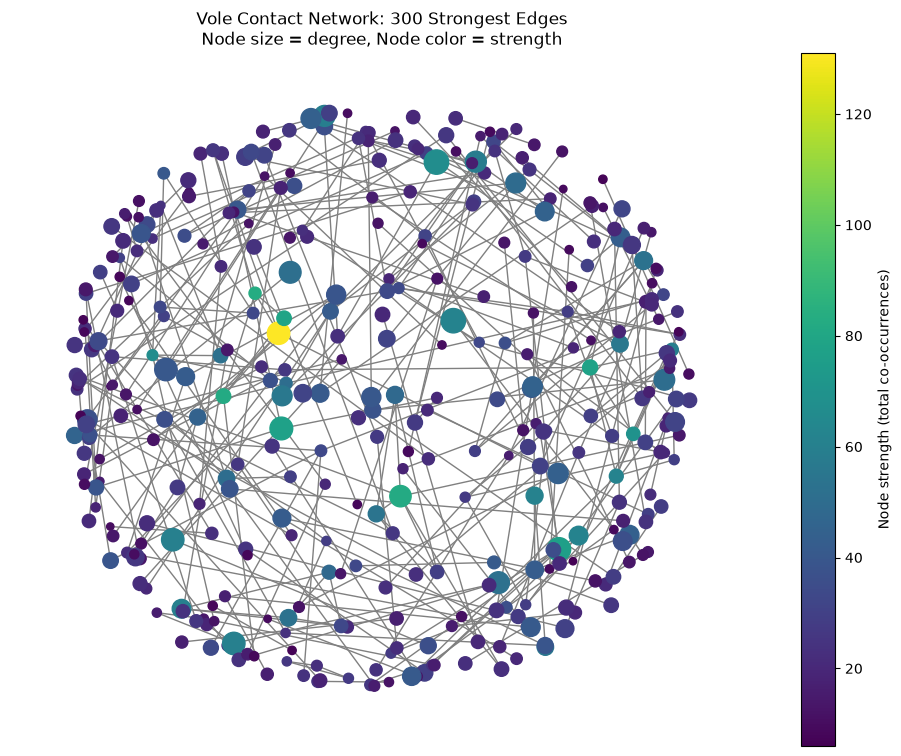

In [22]:

# let's visualize just the strongest edges
top_edges = sorted(
    G.edges(data=True),
    key=lambda edge: edge[2]["weight"],
    reverse=True
)[:300]
H = nx.Graph()
H.add_edges_from(top_edges)
pos = nx.spring_layout(H, seed=10, k=1)
plt.figure(figsize=(12, 9))
# degree: number of distinct voles each vole was seen with (unweighted)
# strength: the sum of the weights on a vole's edges
# both come from the full graph G, not H
degree = dict(G.degree())
strength = dict(G.degree(weight="weight"))
node_sizes = [20 + 8 * degree[node] for node in H.nodes()]
node_strengths = [strength[node] for node in H.nodes()]
color_map = sns.color_palette("viridis", as_cmap=True)
nx.draw_networkx(
    H,
    pos=pos,
    node_size=node_sizes,
    node_color=node_strengths,
    cmap=color_map,
    edge_color="gray",
    with_labels=False,       
)
# add a legend for the color
sm = plt.cm.ScalarMappable(
    cmap=color_map,
    norm=Normalize(vmin=min(node_strengths), vmax=max(node_strengths)),
)
plt.colorbar(sm, ax=plt.gca(), label="Node strength (total co-occurrences)")
plt.axis("off")
plt.title("Vole Contact Network: 300 Strongest Edges\nNode size = degree, Node color = strength")
plt.show()       


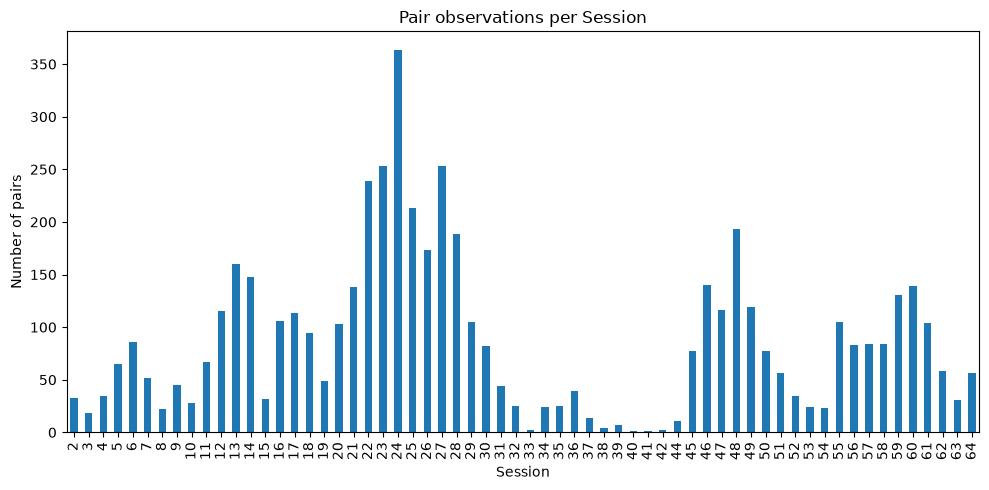

In [23]:
plt.figure(figsize=(10, 5))
# lets look at which sessions the edges are coming from. we need to use the network_df, not G
#since we dumped the sessions earlier from G
network_df["s"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Session")
plt.ylabel("Number of pairs")
plt.title("Pair observations per Session")
plt.tight_layout() 
plt.show()

The key takeaway here from the paper is that the voles are only considered co-located if they came from consecutive trapping sessions, so time-distant voles can not be connected. This would affect distributions if we randomly rewire. 

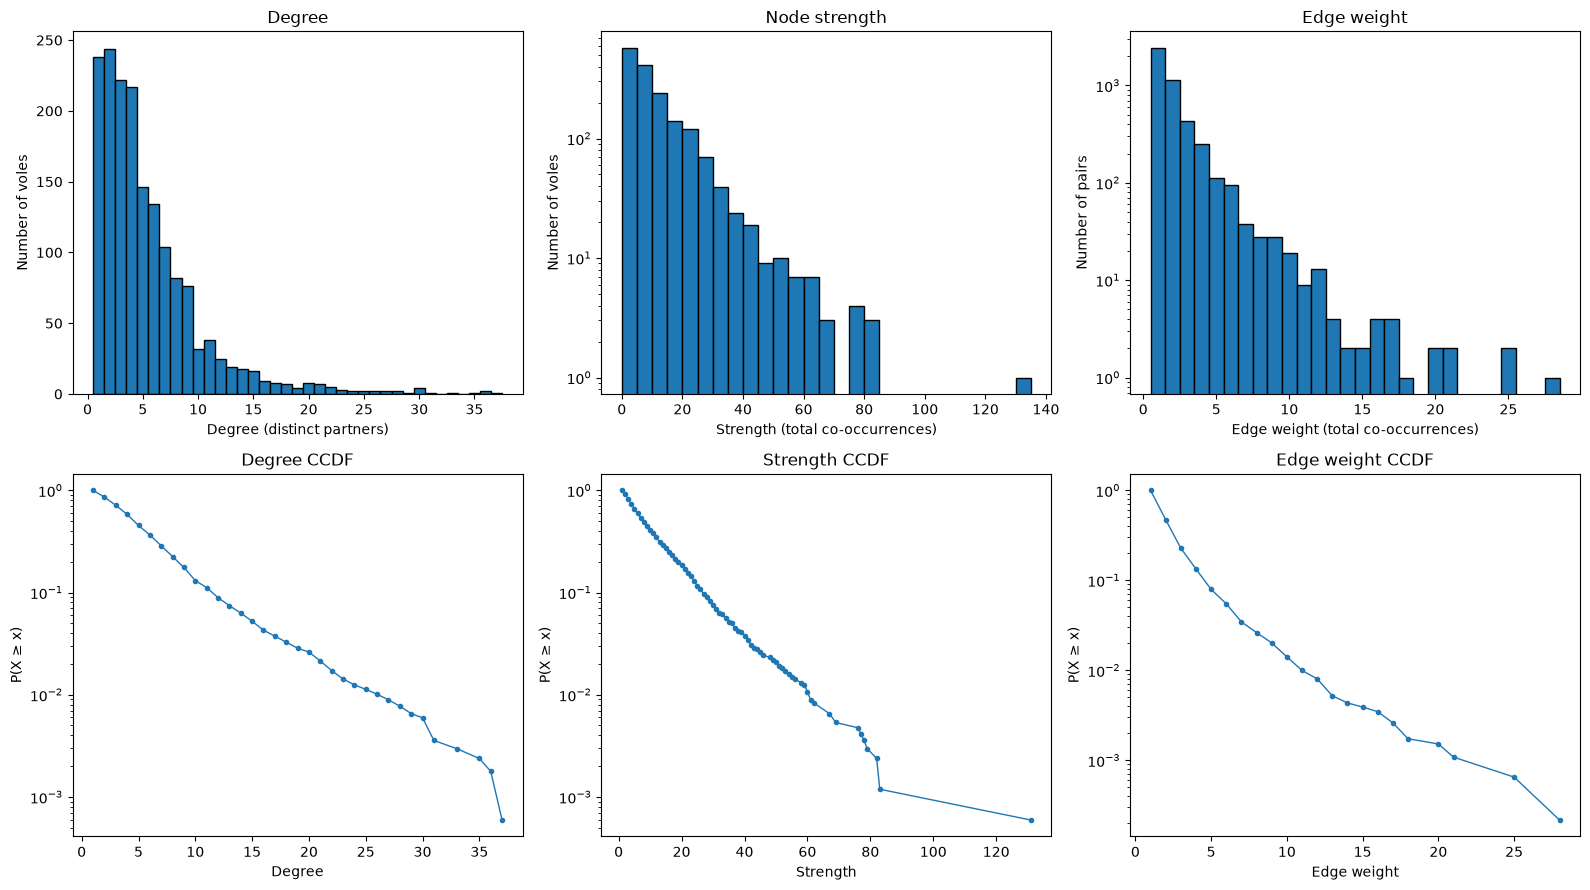

In [26]:
# OLD DISTRIBUTIONS PLOTS (decided to use different measures, see below)

# node and edge properties from the full aggregated graph G
degrees = list(degree.values())
strengths = list(strength.values())
# total co-occurrences per pair
weights = list(nx.get_edge_attributes(G, "weight").values())   
def ccdf(values):
    # P(X >= x) at each distinct value x
    x, counts = np.unique(values, return_counts=True)
    p = 1 - (np.cumsum(counts) - counts) / len(values)
    return x, p

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# histograms
# degree: one bin per value
axes[0, 0].hist(degrees, bins=np.arange(min(degrees) - 0.5, max(degrees) + 1.5, 1), edgecolor="black")
axes[0, 0].set_xlabel("Degree (distinct partners)")
axes[0, 0].set_ylabel("Number of voles")
axes[0, 0].set_title("Degree")

# strength: larger range, wider bins
axes[0, 1].hist(strengths, bins=np.arange(0, max(strengths) + 5, 5), edgecolor="black")
axes[0, 1].set_yscale("log")
axes[0, 1].set_xlabel("Strength (total co-occurrences)")
axes[0, 1].set_ylabel("Number of voles")
axes[0, 1].set_title("Node strength")

# edge weight: one bin per value
axes[0, 2].hist(weights, bins=np.arange(0.5, max(weights) + 1.5, 1), edgecolor="black")
axes[0, 2].set_yscale("log")
axes[0, 2].set_xlabel("Edge weight (total co-occurrences)")
axes[0, 2].set_ylabel("Number of pairs")
axes[0, 2].set_title("Edge weight")

# the same three quantities as CCDFs.
# log y, linear x
for ax, values, xlabel in zip(
    axes[1],
    [degrees, strengths, weights],
    ["Degree", "Strength", "Edge weight"],
):
    x, p = ccdf(values)
    ax.semilogy(x, p, marker="o", markersize=3, linewidth=1)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("P(X ≥ x)")
    ax.set_title(f"{xlabel} CCDF")

fig.tight_layout()
plt.show()


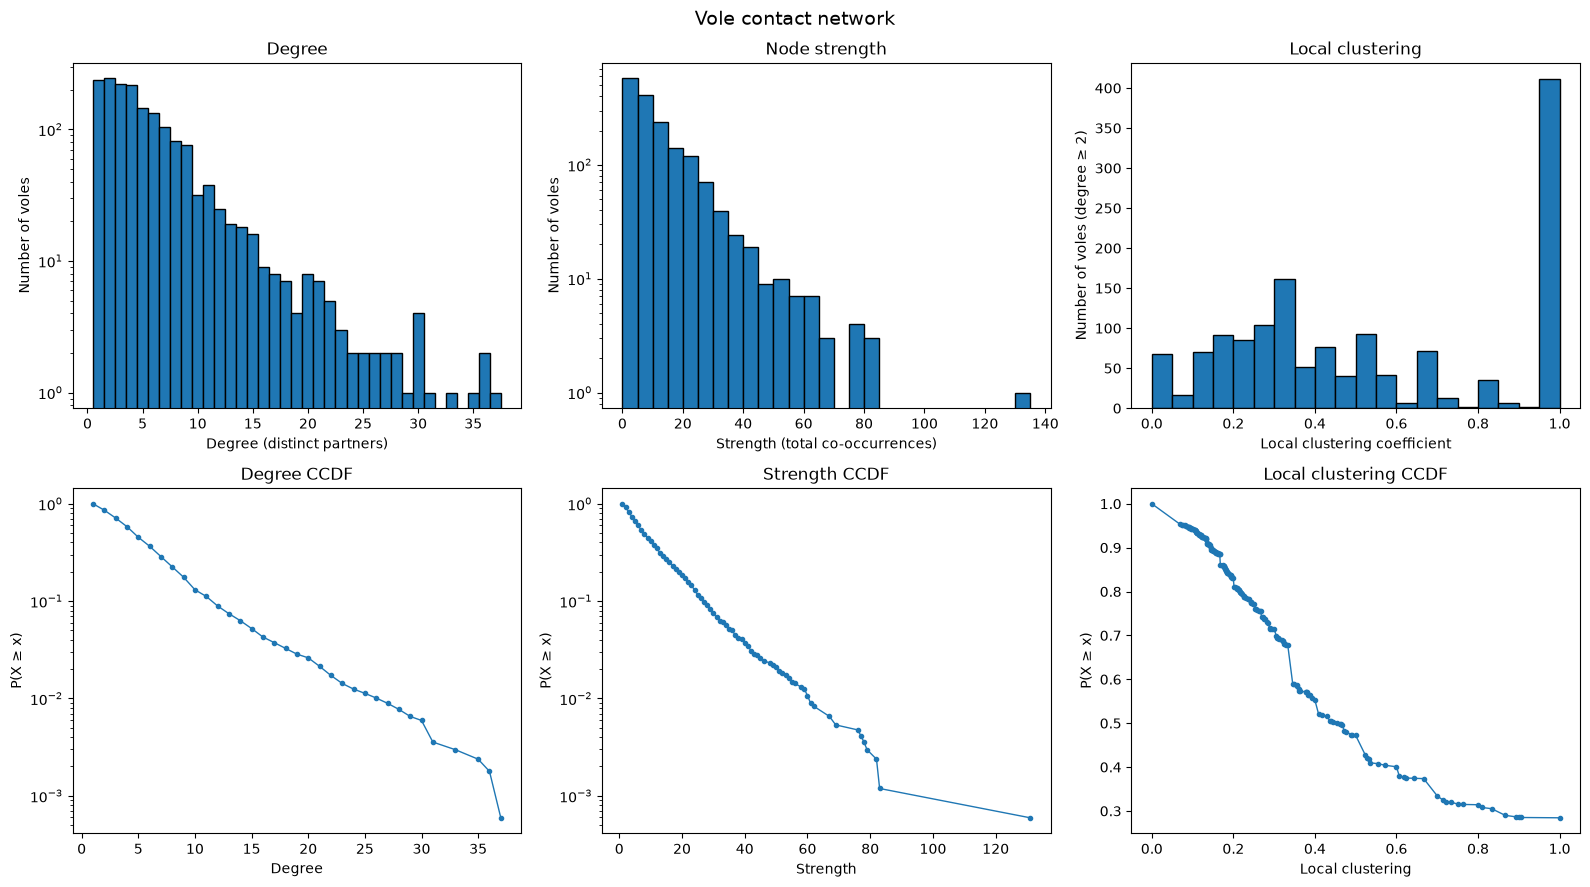

In [27]:
def distributions(graph):
    degree_d = dict(graph.degree())
    strength_d = dict(graph.degree(weight="weight"))
    clust_d = nx.clustering(graph)
    return {
        "Degree": list(degree_d.values()),
        "Strength": list(strength_d.values()),
        "Local clustering": [clust_d[n] for n in graph if degree_d[n] >= 2],
    }

def ccdf(values):
    # P(X >= x) at each distinct value x
    x, counts = np.unique(values, return_counts=True)
    p = 1 - (np.cumsum(counts) - counts) / len(values)
    return x, p

def plot_distributions(dists, title):
    deg, stren, clust = dists["Degree"], dists["Strength"], dists["Local clustering"]
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))

    # histograms
    # degree: one bin per integer
    axes[0, 0].hist(deg, bins=np.arange(0.5, max(deg) + 1.5, 1), edgecolor="black")
    axes[0, 0].set_yscale("log")
    axes[0, 0].set_xlabel("Degree (distinct partners)")
    axes[0, 0].set_ylabel("Number of voles")
    axes[0, 0].set_title("Degree")

    # strength: larger range, width-5 bins
    axes[0, 1].hist(stren, bins=np.arange(0, max(stren) + 5, 5), edgecolor="black")
    axes[0, 1].set_yscale("log")
    axes[0, 1].set_xlabel("Strength (total co-occurrences)")
    axes[0, 1].set_ylabel("Number of voles")
    axes[0, 1].set_title("Node strength")

    # clustering: bounded in [0, 1], 20 equal bins
    axes[0, 2].hist(clust, bins=np.linspace(0, 1, 21), edgecolor="black")
    axes[0, 2].set_xlabel("Local clustering coefficient")
    axes[0, 2].set_ylabel("Number of voles (degree ≥ 2)")
    axes[0, 2].set_title("Local clustering")

    for ax, (name, values) in zip(axes[1], dists.items()):
        x, p = ccdf(values)
        ax.plot(x, p, marker="o", markersize=3, linewidth=1)
        if name != "Local clustering":
            ax.set_yscale("log")
        ax.set_xlabel(name)
        ax.set_ylabel("P(X ≥ x)")
        ax.set_title(f"{name} CCDF")

    fig.suptitle(title, fontsize=14)
    fig.tight_layout()
    return fig, axes

real_dists = distributions(G)
plot_distributions(real_dists, "Vole contact network")
plt.show()


### Part i: distributions of the vole network

The top row shows histograms of three node properties; the bottom row shows the same three as CCDFs, P(X ≥ x), which use every data point without binning and make the shape of the tails easier to judge.

**Binning.** Degree is an integer with a small range (1–37), so it uses one bin per value; wider bins would merge different degrees and make some bars artificially tall. Strength spans 1–131, so I used wider bins. Local clustering is bounded in [0, 1], so it uses 20 equal bins of width 0.05. 

- **Degree.** Most voles had few distinct partners: the median is 4 and the mean 5.5, and the most common degrees are 1–3. The distribution is right-skewed with a tail to 37. The CCDF is close to a straight line on a log-y, linear-x scale, indicating a roughly exponential tail rather than a power law, so there are no extreme hubs.
- **Strength.** Total co-occurrences are more spread out than degree (median 7, mean 11.6), because repeated contact with the same partner adds to strength but not to degree. The tail is again roughly exponential, apart from one outlier vole at 131.
- **Local clustering.** Clustering is high: among the 1,445 voles with degree ≥ 2 (it is undefined below that), the mean is 0.54. 28% of them have clustering exactly 1, meaning all of their partners were also partners of each other. This spike is likely built into how the network was made: voles trapped together in a session are all linked to each other, which creates complete triangles.


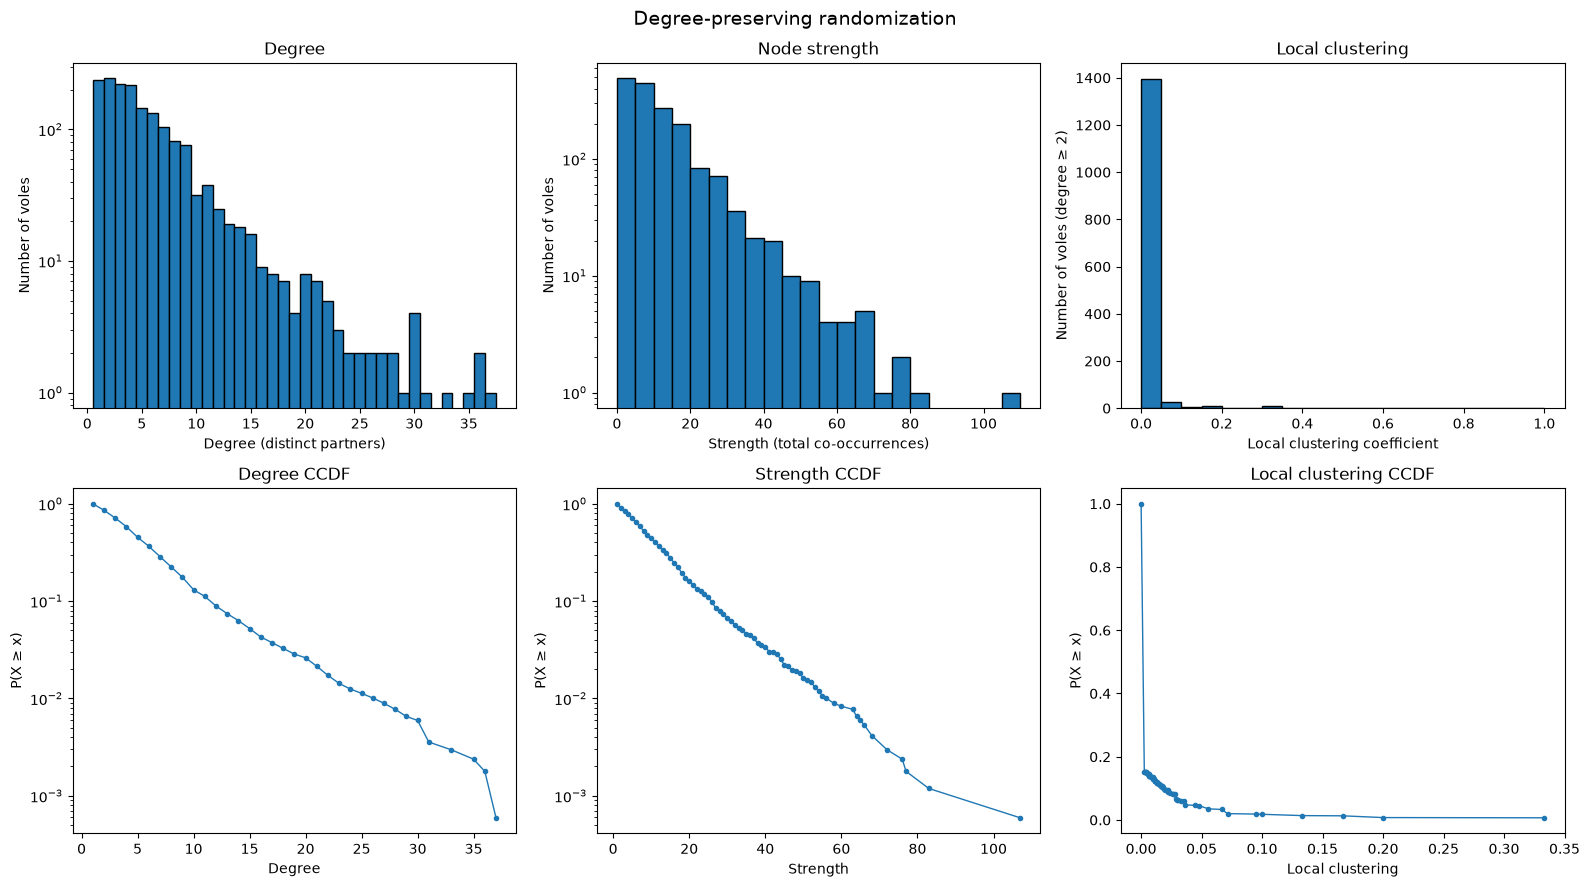

In [28]:
rng = np.random.default_rng(10)
# randomized copy with edges rewired, preserving degree
G_rand = nx.Graph(G.edges())
nx.double_edge_swap(G_rand, nswap=10 * G_rand.number_of_edges(), max_tries=10**7, seed=10)
# assign the real weights to rewired edges in random order
real_weights = [w for _, _, w in G.edges(data="weight")]
for (u, v), w in zip(G_rand.edges(), rng.permutation(real_weights)):
    G_rand[u][v]["weight"] = int(w)

# confirmation: same degree sequence as the real network
if dict(G_rand.degree()) != dict(G.degree()):
    raise ValueError("Randomized network does not preserve the degree sequence")
rand_dists = distributions(G_rand)
plot_distributions(rand_dists, "Degree-preserving randomization")
plt.show()


### Part ii: distributions of the randomized network

The randomized network was made by degree-preserving rewiring (`nx.double_edge_swap`, about 10× as many swaps as edges). Rewiring creates new edges with no weights, so I assigned the real edge weights to the new edges in random order. That keeps the total weight and the weight distribution, while randomizing which voles get the heavy ties. The bins and axes match part i.

- **Degree.** Identical to the real network, by construction. This confirms the null model preserves the degree sequence.
- **Strength.** The mean is unchanged (11.6), since total weight is preserved, but the distribution is narrower: the maximum drops from 131 to 91 and the spread shrinks slightly [check]. In the randomized network, strength follows degree more closely (correlation 0.90 vs. 0.83 in the real network). In the real network, heavy repeated contact is concentrated on particular voles more than chance would predict. These differences are modest and come from a single randomization.
- **Local clustering.** Clustering almost disappears: the mean falls from 0.54 to 0.006, 87.5% of voles have clustering exactly 0, and none have clustering 1 (vs. 28% in the real network) [check]. This is the main result. The real network's tight local groups are not a consequence of its degree distribution; they reflect how contacts actually happen, through co-trapping in groups and local contact. The 20-randomization comparison below confirms this one randomization is typical.


In [29]:
# extra: summary statistics over 50 randomizations, to check that the part ii
# figure (one random draw) is typical of the null model, not a fluke
G_unw = nx.Graph(G.edges())   # unweighted: these measures don't use weights

def props(graph):
    # path length is only defined within a connected piece, so use the largest component
    lcc = graph.subgraph(max(nx.connected_components(graph), key=len))
    return {
        "avg_clustering": nx.average_clustering(graph),
        "transitivity": nx.transitivity(graph),
        "degree_assortativity": nx.degree_assortativity_coefficient(graph),
        "lcc_fraction": len(lcc) / graph.number_of_nodes(),
        "avg_path_length_lcc": nx.average_shortest_path_length(lcc),
    }

n_rand = 50   # it is a bit slow, but ran roughly in 3min                   
rng_null = np.random.default_rng(10)
null = []
for _ in range(n_rand):
    G_null = G_unw.copy()
    nx.double_edge_swap(
        G_null,
        nswap=10 * G_null.number_of_edges(),
        max_tries=10**7,
        seed=int(rng_null.integers(1e9)),
    )
    null.append(props(G_null))

null_df = pd.DataFrame(null)
obs = pd.Series(props(G_unw))
summary = pd.DataFrame({
    "observed": obs,
    "null_mean": null_df.mean(),
    "null_std": null_df.std(),
    "z_score": (obs - null_df.mean()) / null_df.std(),
})
print(summary.round(4))


                      observed  null_mean  null_std   z_score
avg_clustering          0.4623     0.0073    0.0010  436.6470
transitivity            0.2679     0.0082    0.0009  276.9120
degree_assortativity    0.0250    -0.0078    0.0162    2.0267
lcc_fraction            0.9566     0.9960    0.0021  -18.6678
avg_path_length_lcc     7.3731     4.2225    0.0112  281.7816


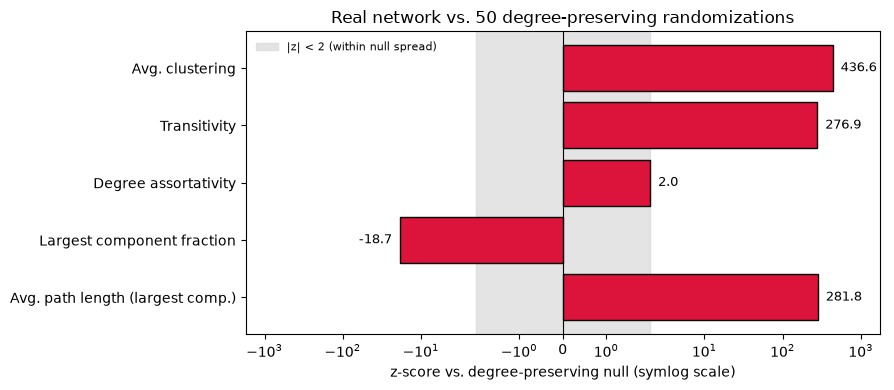

In [30]:
# z-score of each property: how many null standard deviations the real value
# sits from the mean of the randomized networks
labels = {
    "avg_clustering": "Avg. clustering",
    "transitivity": "Transitivity",
    "degree_assortativity": "Degree assortativity",
    "lcc_fraction": "Largest component fraction",
    "avg_path_length_lcc": "Avg. path length (largest comp.)",
}
z = summary["z_score"].rename(index=labels)[::-1]   # reversed so the first property is on top

fig, ax = plt.subplots(figsize=(9, 4))

# shaded band: |z| < 2, roughly "within the spread of the null"
ax.axvspan(-2, 2, color="lightgray", alpha=0.6, label="|z| < 2 (within null spread)")

# horizontal bars, red if outside the band
colors = ["crimson" if abs(v) >= 2 else "gray" for v in z.values]
ax.barh(z.index, z.values, color=colors, edgecolor="black")
ax.axvline(0, color="black", linewidth=0.8)

# symlog: linear near 0, log beyond, so z of ~2 and ~500 fit on one axis (and negatives work)
ax.set_xscale("symlog", linthresh=2)
lim = max(abs(z.values)) * 4
ax.set_xlim(-lim, lim)

# print each z-score at the end of its bar
for i, v in enumerate(z.values):
    ax.text(v, i, f"  {v:.1f}  ", va="center", ha="left" if v >= 0 else "right", fontsize=9)

ax.set_xlabel("z-score vs. degree-preserving null (symlog scale)")
ax.set_title(f"Real network vs. {len(null_df)} degree-preserving randomizations")
ax.legend(loc="upper left", fontsize=8, frameon=False)
fig.tight_layout()
plt.show()


### Null model: summary statistics across 20 randomizations

**Null model.** I used degree-preserving rewiring (`nx.double_edge_swap`): repeatedly pick two edges S1–T1 and S2–T2 and swap them to S1–T2 and S2–T1, rejecting swaps that would create self-loops or multi-edges. Every vole keeps its exact degree, but who it is connected to is randomized. Each randomized network received about 10× as many swaps as there are edges, as recommended in Class 4. I chose rewiring over the configuration model because it preserves each node's exact degree and never creates self-loops or multi-edges that would have to be removed (removing them changes the degrees). These measures are unweighted, since rewiring does not preserve weights.

The part ii figure shows a single randomization. To check that it is typical rather than a lucky draw, I generated 20 randomized networks and compared five summary properties against them. The z-score is how many standard deviations of the 20 randomized values the real value lies from their mean.

| Property | Real network | Randomized (mean) [check] | z-score |
|---|---|---|---|
| Average clustering | 0.462 | ≈ 0.007 | 423.9 |
| Transitivity | 0.268 | ≈ 0.008 | 417.9 |
| Degree assortativity | 0.025 | ≈ −0.01 | 1.8 |
| Largest-component fraction | 0.957 | ≈ 0.996 | −24.7 |
| Avg. path length (largest component) | 7.37 | ≈ 4.2 | 248.1 |

**Interpretation.**
- **Clustering is far beyond the null.** Average clustering is roughly 60× the randomized value and transitivity roughly 30×, with z-scores above 400. The degree sequence cannot produce this. Two features of the data likely contribute: voles trapped together in the same session are all linked to each other, which creates complete triangles; and contacts are local, so a vole's partners tend to share partners.
- **Paths are much longer, and the network is less connected.** The real network's average path length (7.4) is far above the randomized ones (≈ 4.2), and fewer voles fall in its largest component (95.7% vs. ≈ 99.6%). Rewiring creates shortcuts between voles that could never have met. This network is aggregated over 64 trapping sessions, and voles from distant sessions likely never coexisted, so the real network lacks those shortcuts. It is highly clustered but *not* small-world.
- **Degree assortativity is consistent with the null.** Its z-score (1.8) is inside the ±2 band. The real value is slightly positive and sits just above the 20 randomized values, so at most there is a weak tendency for high-degree voles to contact each other. More randomizations would be needed to say whether it is real.

**Caveats.** With only 20 randomizations and very small spread among them, the large z-scores mean "far outside the null" rather than precise magnitudes. The path-length comparison is over slightly different node sets, because the real network's largest component is smaller.
